# Predicting Housing Market Responses to Short-Term Rental Regulation in New Orleans

## Milestone 1: Project Plan & Exploratory Analysis
**Author:** Maya Gore  
**Github:** https://github.com/mayaagore/mayaagore.github.io/tree/main  
**Webpage:** https://mayaagore.github.io/     
**Data Source:** City of New Orleans, [Geocode API]  

---
### Project Overview & Plan
If you want to spark a lively debate around a New Orleans dinner table, bring up Airbnb.
Regulating short-term rentals (STR) has come to represent a debate about affordability, cultural
stability, and the responsibilities of local government.  
  
New Orleans provides a particularly interesting setting for studying these dynamics becuase the city has introduced several waves of STR regulation over the past decade. After legalizing STRs in 2016, the City began tightening restrictions in response to community concerns. In August 2019, the City adopted regulations to tighten zoning limitations and require individual permit holders to have homestead tax exemptions and occupancy limits for the permitted property. In the natural rhythm of the city, STR underwent a third regulatory wave in 2023 alongside cost-of-living concerns from the COVID-19 pandemic. Stricter regulations were passed allowing up to three STR permits per city block distributed by lottery system and applied to within Orleans Parish, excepting the French Quarter and Garden District, where STRs are entirely banned.  
  
This project will combine publically available STR permit data from the City of New Orleans, neighborhood-level information from the U.S. Census American Community Survey, and potentiall scraped property-evel records from the Orleans Parish Assessor to examine how neihgborhoods respond to STR regulation, and predict how particular types of units will respond?   
  
**Central Research Quesion:**  Do STR permit regulations cause units to transition into long-term housing supply? Do neighborhoods see measurable changes in occupancy, rental rates, or housing values? Using property and listing characteristics, can we predict which STR porperties are most likely to exit the STR market following regulations?


### Project Datasets   
  
#### 1. STR Permit Applications, City of New Orleans *(primary dataset for M1)*
**Source:** https://data.nola.gov/Housing-Land-Use-and-Blight/Short-Term-Rental-Permit-Applications/en36-xvxg/about_data    
**Coverage:** individual permit application,  2017 to 2025, 35,952 applications   
  
This is the core dataset and the primary data examined for Milestone 1. It contains the application for every STR permit in New Orleans including withdrawls and rejections, and captures the permit type, residential subtype, status (and date of issue, date of application), operator name, capacity, and GPS coordinates. It captures the regulatory history of the STR market in New Orleans.  
  
This dataset can answer questions about whether STR permit activity changed around periods of regulatory change. 

#### 1a. Census Bureau reverse geocoding API  
**Source:** https://geocoding.geo.census.gov/geocoder/geographies/coordinates      
  
Each set of GPS coordinates from the STR permit application dataset were matched to their census tract utilizing the coordinate lookup provided by the U.S. Census Bureau.  
  
#### 2. American Community Survey (ACS) 5-Year Estimates, IPUMS *(pending M2)*  
**Source:** https://usa.ipums.org/usa-action/revisions#revision_2_27_2025    
**Coverage:** 5-year census track panel data by year (2014-2024), and 1-year available for 2024  
  
The ACS provides tract-level housing and demographic variables included total housing units within the tract, owner- and renter-occupation status, median rent, median home value, and median houshold income.  
  
This dataset will be utilized to obeserve housing market changes around the regulatory cutoff and downstream housing supply effects. It will help answer if renter occupancy rate increase in high-STR areas after regulation, and whether median rents declined.  
  
#### 3. Inside Airbnb New Orleans listings *(pending M2)*  
**Source:** https://insideairbnb.com/get-the-data/    
**Coverage:** Airbnb listings 1 year prior to download, with additional years available upon request 
  
As referenced, there have been enforcement issues aurrounding STR permitting regulations. Due to potential discrepancies between lisitngs and permits, this dataset can be compared to STR permits to ask similar quesitons about changes to listings surrounding regulatory cutoffs. 

---
### Extract, Transform & Load: STR Permits

In [63]:
%pip install numpy pandas requests
import re
import time
import numpy as np
import pandas as pd
import requests
import os
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Set the directory:

In [64]:
os.chdir("/Users/mayagore/Library/CloudStorage/OneDrive-TulaneUniversity/26S Data Science/Project/Data")

#### Step 1. Load csv & clean permit variables.  
  
Ensure tidy data by checking the following:  
* Each row is one permit application  
* Each column is one variable  
* categorical strings encoded  
* Date strings parsed  
* GPS string separated into latitude and longitude (for Step 2)  

In [65]:
df = pd.read_csv("Short-Term_Rental_Permit_Applications_20250929.csv")

# check what's in the dataset
df.head()

# fix naming inconsistencies and make column names more code-friendly
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

# fix permit number formatting and convert to numeric (coercing errors to NaN)
df["permit_number"] = pd.to_numeric(df["permit_number"], errors="coerce")

## Set categorical variable mapping as integer codes------------
# permit type map
perm_type_map = {
    "Interim STR":                            1,
    "Non-Commercial STR - Special Exception": 2,
    "Non-Commercial Short Term Rental":       3,
    "Short Term Rental":                      4,
    "Short Term Rental Commercial Owner":     5,
    "Short Term Rental Residential Owner":    6,
    "N/A":                                    0,
}
df["perm_type"] = df["permit_type"].map(perm_type_map)

# residential subtype map
res_type_map = {
    "Accessory STR":            1,
    "Commercial STR":           2,
    "Interim":                  3,
    "Residential Large Unit":   4,
    "Residential Partial Unit": 5,
    "Residential Small Unit":   6,
    "Temporary STR":            7,
    "N/A":                      0,
}
df["res_type"] = df["residential_subtype"].map(res_type_map)

# permit status map
status_map = {
    "Denied":    1,
    "Duplicate": 2,
    "Expired":   3,
    "Issued":    4,
    "Pending":   5,
    "Revoked":   6,
    "Withdrawn": 7,
}
df["status"] = df["current_status"].map(status_map)
#---------------------------------------------------

# expired status dummy variable
df["exp_"] = df["expired"].map({"Yes": 1, "No": 0})

# clean date variables
df["exp_date"] = pd.to_datetime(df["expiration_date"], errors="coerce")
df["iss_date"] = pd.to_datetime(df["issue_date"], errors="coerce")
df["app_date"] = pd.to_datetime(df["application_date"], errors="coerce")

# create month-year and year variables for application date for time-series grouping
df["app_moyr"] = df["app_date"].dt.to_period("M")
df["app_year"] = df["app_date"].dt.year

# encode string IDs
for src, dst in [("operator_name", "operator_id"), ("operator_permit_number", "operator_permit_id")]:
    df[dst] = df[src].astype("category").cat.codes + 1  # +1 to avoid confusion with -1 for NaN

# parse location into lat/lon variables
def parse_latlon(s):
    try:
        nums = re.findall(r"[-+]?\d*\.\d+|\d+", str(s))
        if len(nums) == 2:
            return float(nums[0]), float(nums[1])
    except Exception:
        pass
    return np.nan, np.nan
laton = df["location"].apply(parse_latlon)
df["latitude"] = laton.apply(lambda x: x[0])
df["longitude"] = laton.apply(lambda x: x[1])

# check the cleaned dataset
df.head()
#df.dtypes

,permit_number,address,permit_type,residential_subtype,current_status,expired,expiration_date,bedroom_limit,guest_occupancy_limit,link,...,exp_,exp_date,iss_date,app_date,app_moyr,app_year,operator_id,operator_permit_id,latitude,longitude
0,NaN,NaN,Short Term Rental,NaN,Pending,No,NaN,NaN,NaN,https://onestopapp.nola.gov/Redirect.aspx?Sear...,...,0,NaT,NaT,NaT,NaT,NaN,0,0,29.920602,-90.110274
1,NaN,NaN,Short Term Rental,NaN,Denied,Yes,NaN,NaN,NaN,https://onestopapp.nola.gov/Redirect.aspx?Sear...,...,1,NaT,NaT,2023-01-26,2023-01,2023.0,0,0,28.098891,-101.517799
2,NaN,212 Loyola Ave Unit 1205,Short Term Rental,Commercial STR,Revoked,Yes,NaN,NaN,4.0,https://onestopapp.nola.gov/Redirect.aspx?Sear...,...,1,NaT,2018-04-10,2018-04-10,2018-04,2018.0,0,0,29.954276,-90.074632
3,NaN,NaN,Short Term Rental,Accessory STR,Withdrawn,Yes,NaN,NaN,NaN,https://onestopapp.nola.gov/Redirect.aspx?Sear...,...,1,NaT,NaT,2017-10-09,2017-10,2017.0,2080,0,29.953576,-90.053063
4,NaN,416 Park Blvd,Short Term Rental,Accessory STR,Denied,Yes,NaN,NaN,NaN,https://onestopapp.nola.gov/Redirect.aspx?Sear...,...,1,NaT,NaT,2017-04-04,2017-04,2017.0,0,0,29.939830,-90.051158


---
### Step 2. Geocode coordinates to census tracts.
**Please note: the geocoding portion takes a few hours to run. The process written below exports a STRs_cleaned.csv which has been uploaded to the Github and which can be read in directly at Step 3!**   
  
The STR permits include addesses & coordinates, but no zipcode or census tract id. I want to ultimately merge this data with ACS, so I need to merge in a geographical unit to match the ACS unit of observation.  
  
*(disclosure: because this is outside what we have covered in class thus far, I received help with this portion)*

This is how I used the census geocoder to match coordinates to their census tract, recorded here as text to avoid re-running the process:  

```python  
# create a boundary for New Orleans
nola_mask = (
    (df["latitude"] >= 29.85) & (df["latitude"] <= 30.10) &
    (df["longitude"] >= -90.30) & (df["longitude"] <= -89.90)
)
print(nola_mask.sum())

# print out the number of observations within NOLA as a sanity check
total_obs      = len(df)
invalid_coords = df["latitude"].isna().sum()
outside_nola   = (~df.apply(
    lambda r: nola_mask.loc[r.name], axis=1
)).sum()
inside_nola    = total_obs - outside_nola
print(f"Total STR observations:          {total_obs}")
print(f"Invalid/missing coordinates:     {invalid_coords}")
print(f"Outside New Orleans bounds:      {outside_nola}")
print(f"Inside New Orleans bounds:       {inside_nola}")

#remove duplicates from coordinates to minimize repeat searches
coords = (
    df[nola_mask][["latitude", "longitude"]]
    .drop_duplicates()
)
print(f"\nUnique coordinate pairs to geocode: {len(coords)}")

# set up geocode coordinates to census tracts using Census Geocoder API
def geocode_coord(lat, lon):
    """Return 11-digit census tract GEOID, or '' on failure."""
    url = ("https://geocoding.geo.census.gov/geocoder/geographies/coordinates"
        f"?x={lon}&y={lat}&benchmark=Public_AR_Current&vintage=Current_Current&format=json"
    )
    for _ in range(3):  # retry up to 3 times
        try:
            r = requests.get(url, timeout=5).json()
            geos = r["result"]["geographies"].get("Census Tracts", [])
            if geos:
                return geos[0]["GEOID"]
            return ""
        except Exception:
            time.sleep(1)  # wait before retrying
    return ""

# run geocode and save to a dictionary
coord_to_tract = {}
for i, row in coords.iterrows():
    lat, lon = row["latitude"], row["longitude"]
    coord_to_tract[(lat, lon)] = geocode_coord(lat, lon)
    if i % 100 == 0:
        print(f"Processed {i} pairs")

# match GEOIDs back to main dataframe
df["tract_geoid"] = df.apply(
    lambda row: coord_to_tract.get((row["latitude"], row["longitude"]), ""),
    axis=1
)   

# format GEOID as a string--this is important for merging with census data later
df["tract_geoid"] = df["tract_geoid"].astype(str).str.zfill

## OUTPUT
df.to_csv("STRs_cleaned.csv", index=False)
```


---
### Step 3. Regulation Timing and Trends
I am reading in the saved .csv output from step 3 above with the census tract GEOIDs. This is to simplify and cut out repeat runs of the time-consuing geocoding process.

Regulations went into effect in August of 2019 and March of 2023. Here I am creating dates for those cutoffs.

In [66]:
# read in the updated dataset with the census tract GEOIDs
df = pd.read_csv("STRs_cleaned.csv")
df["app_date"] = pd.to_datetime(df["app_date"], errors="coerce")
df["app_moyr"] = df["app_date"].dt.to_period("M")
df["app_year"] = df["app_date"].dt.year

In [67]:
# drop duplicates from status_map
df = df[df["status"] != 2] # 2 = 'duplicate'
df = df[df["status"] != 7] # 7 = 'withdrawn'
df = df[df["status"].notna()] 

# compute next application date at same address
df = df.sort_values(["address", "app_date"]).reset_index(drop=True)
df["next_app_date"] = df.groupby("address")["app_date"].shift(-1)
df["next_status"]   = df.groupby("address")["status"].shift(-1)

# set regulation periods (August 2019 ordinance & March 2023 ordinance)
reg_23_cutoff = pd.Period("2023-03", freq="M")      # March 2023
reg_18_cutoff = pd.Period("2019-08", freq="M")      # August 2019
df["reg_23"] = (df["app_moyr"] >= reg_23_cutoff).astype(int)
df["reg_18"] = (df["app_moyr"] >= reg_18_cutoff).astype(int)        

print(df[["reg_18", "reg_23"]].describe())

# create permit lengths 
df["exp_date"] = pd.to_datetime(df["exp_date"], errors="coerce")
df["next_app_date"] = pd.to_datetime(df["next_app_date"], errors="coerce")

df["days_to_next"] = (df["next_app_date"] - df["exp_date"]).dt.days

# create indicator for a market exit if there was no second application at the address, or it was over 180 days (6 months)
df["market_exit"] = np.nan
expired_mask = df["status"] == 3  # 3 = 'expired'
df.loc[expired_mask & df["days_to_next"].isna(), "market_exit"] = 1
df.loc[expired_mask & (df["days_to_next"] > 180), "market_exit"] = 1
df.loc[expired_mask & (df["days_to_next"] <= 180), "market_exit"] = 0

print(df["market_exit"].value_counts())

            reg_18        reg_23
count  33174.00000  33174.000000
mean       0.55646      0.233315
std        0.49681      0.422948
min        0.00000      0.000000
25%        0.00000      0.000000
50%        1.00000      0.000000
75%        1.00000      0.000000
max        1.00000      1.000000
market_exit
0.0    10044
1.0     8809
Name: count, dtype: int64


---
## Exploratory Data Analysis

**A. Market Exits:**  Market exits over time, relative to 2019 and 2023 regulations.

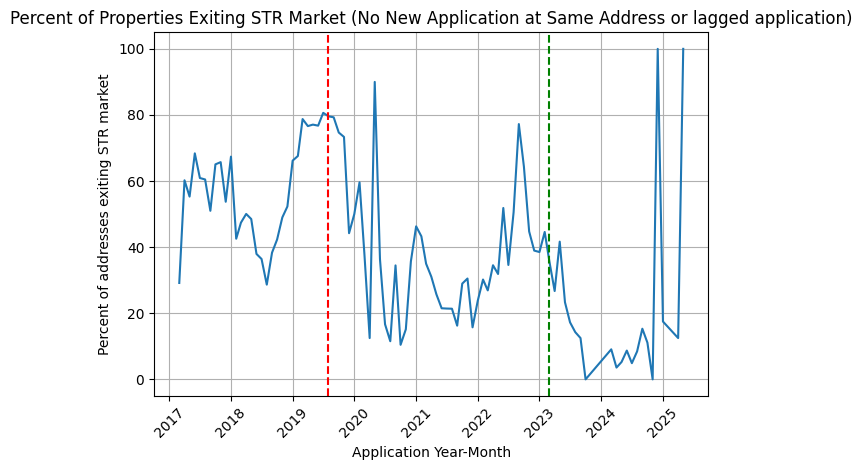

In [68]:
## Are expired permits being replaced by new applications at the same address?
exit_by_month = df[df["status"] == 3].groupby("app_moyr")["market_exit"].mean() *100
exit_by_month.index = exit_by_month.index.to_timestamp()

# visualize percent of expired permits with market exit by application month
plt.plot(exit_by_month.index, exit_by_month.values)
plt.axvline(pd.Timestamp("2019-08-01"), color="red", linestyle="--", label="Aug 2019 Reg") 
plt.axvline(pd.Timestamp("2023-03-01"), color="green", linestyle="--", label="Mar 2023 Reg")
plt.title("Percent of Properties Exiting STR Market (No New Application at Same Address or lagged application)")
plt.xlabel("Application Year-Month")
plt.ylabel("Percent of addresses exiting STR market")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

**B. Operator Size Distribution:** how many units do operators hold? I want to capture the number of units permitted to individual operators, capturing properties with continuously renewing permits as one unit.

count    11218.000000
mean         1.881262
std         22.106338
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max       2289.000000
Name: address, dtype: float64


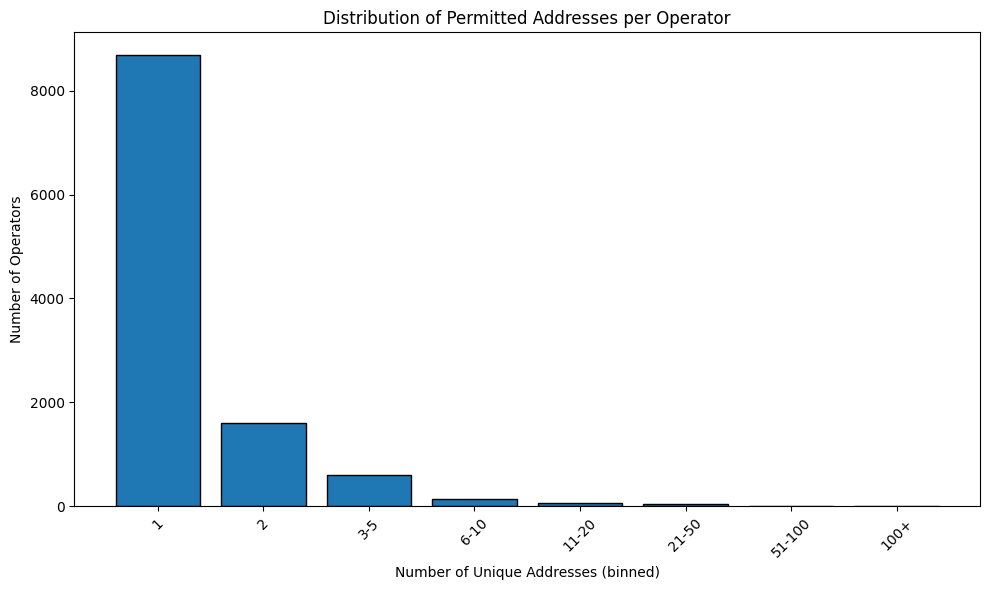

In [69]:
# count the number of unique addresses by operator
address_counts = df.groupby("operator_id")["address"].nunique().sort_values(ascending=False)
print(address_counts.describe())

# visualize distribution of unique addresses per operator
buckets = pd.cut(address_counts, bins=[0, 1, 2, 5, 10, 20, 50, 100, np.inf], labels=["1", "2", "3-5", "6-10", "11-20", "21-50", "51-100", "100+"], right=True)
bucket_counts = buckets.value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(bucket_counts.index.astype(str), bucket_counts.values, edgecolor="k")
plt.title("Distribution of Permitted Addresses per Operator")
plt.xlabel("Number of Unique Addresses (binned)")
plt.ylabel("Number of Operators")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**C. Applications over Time:** How do the number of applications change over time relative to regulatory changes?

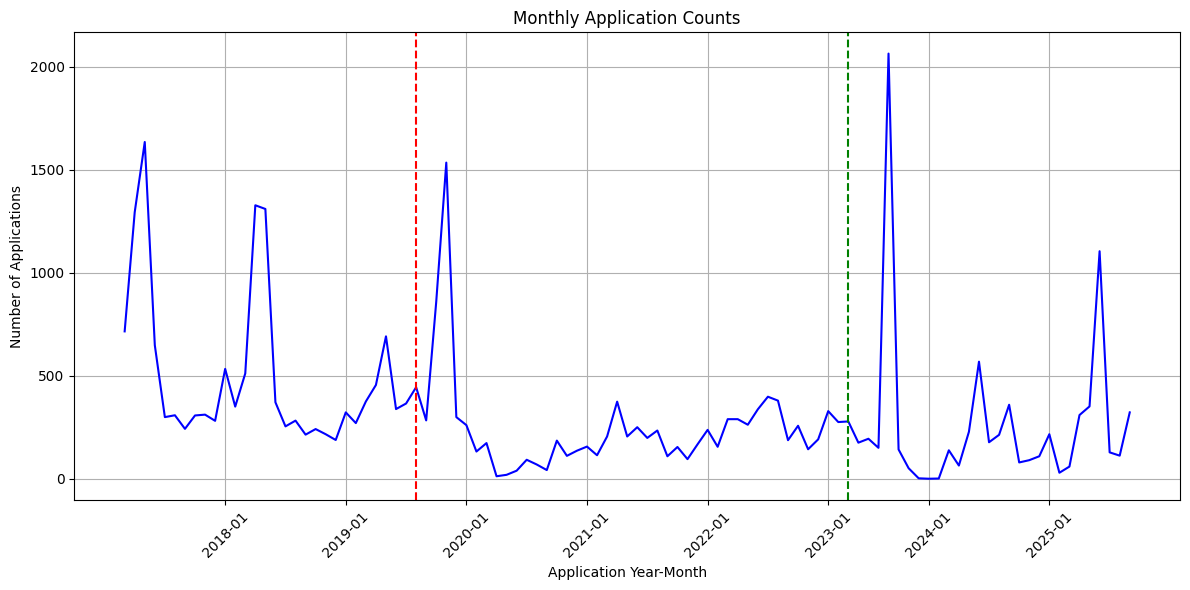

In [70]:
# monthly application counts
monthly_counts = df.groupby("app_moyr").size().reset_index(name="application_count")
monthly_counts["app_moyr"] = monthly_counts["app_moyr"].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(monthly_counts["app_moyr"], monthly_counts["application_count"],color="blue")

#regulation period lines
plt.axvline("2019-08", color="red", linestyle="--", label="Aug 2019 Reg") 
plt.axvline("2023-03", color="green", linestyle="--", label="Mar 2023 Reg")
plt.title("Monthly Application Counts")
plt.xlabel("Application Year-Month")
plt.ylabel("Number of Applications")
plt.xticks(monthly_counts[monthly_counts["app_moyr"].str.endswith("-01")]["app_moyr"], rotation=45)  # show only January of each year for readability
plt.grid()
plt.tight_layout()
plt.show()


---  
## Next Steps   

In the next steps, I will merge permit data with ACS tract-level panel data 2017-2024 on geoid & year. This will attach tract-level housing outcome variables -- including median gross rent, median home value, onwer- and renter-occupied unit counts, and total housing units. I will also load and join Inside Airbnb data on number of listings over the time period of interest. This will capture actual STR activity and unpermitted properties. 
  
Additioanlly, I will attempt to scrape the New Orleans Tax Assessor's Office public database (https://beacon.schneidercorp.com/Application.aspx?AppID=979&LayerID=19792&PageTypeID=2&PageID=8661) for a sammple of addresses listed on STR permits for parecel-level characteristics and residency information. 

---
#### Github

In [71]:
!jupyter nbconvert --to html "/Users/mayagore/Library/CloudStorage/OneDrive-TulaneUniversity/26S Data Science/Project/Sandbox-STR-M1.ipynb" --output index.html

[NbConvertApp] Converting notebook /Users/mayagore/Library/CloudStorage/OneDrive-TulaneUniversity/26S Data Science/Project/Sandbox-STR-M1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 545176 bytes to /Users/mayagore/Library/CloudStorage/OneDrive-TulaneUniversity/26S Data Science/Project/index.html
